# Test-Bed Data Reduction Exploration

Interactive walk through `jetx.daq` — the same pipeline used by
`scripts/run_project2_data_reduction.py`, used here to inspect intermediate
steps (raw vs. calibrated vs. filtered) that the script only writes to disk.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt

from jetx.daq import calibration, corrected_speed, filtering, qa, synthetic

%matplotlib inline

## 1. Generate the synthetic raw log

See `docs/assumptions_and_limitations.md` for why this data is synthetic
and what that does (and doesn't) mean for the pipeline it exercises.

In [2]:
raw_df = synthetic.generate_raw_test_log()
raw_df.head()

,time_s,load_cell_raw_counts,thermocouple_raw_mv,pressure_transducer_raw_ma,rpm_sensor_pulse_count,fuel_flow_kg_s,ambient_temp_k,ambient_pressure_pa
0,0.0,1004.570756,-0.009724,5.624012,0.072909,0.019630,298.204524,101350.798111
1,0.1,986.779613,0.025714,5.614443,33.753507,0.018981,298.049652,101340.296085
2,0.2,1020.304341,0.045087,5.613267,65.852805,0.021718,298.007827,101311.133915
3,0.3,1033.468865,0.070381,5.606166,96.189486,0.019777,298.131153,101325.796635
4,0.4,1003.482221,0.110204,5.626420,125.281685,0.019953,298.191097,101318.997698


## 2. Calibrate, then compare raw vs. filtered thrust

This is the same Butterworth `filtfilt` filter used in the main pipeline,
applied here to a single channel so the effect is easy to see directly.

2026-07-30 08:37:03 | INFO    | jetx.daq.calibration | Calibrated 1201 samples (thrust, EGT, inlet pressure, RPM); dt=0.1000 s


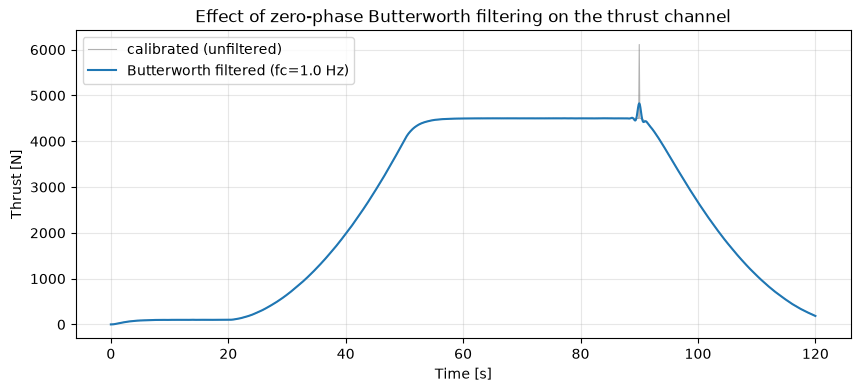

In [3]:
calibrated_df = calibration.apply_calibration(raw_df)
filtered_thrust = filtering.filter_channel(calibrated_df, "thrust_n", sample_rate_hz=10.0, cutoff_hz=1.0)

plt.figure(figsize=(10, 4))
plt.plot(calibrated_df["time_s"], calibrated_df["thrust_n"], color="tab:gray", alpha=0.6, lw=0.8, label="calibrated (unfiltered)")
plt.plot(calibrated_df["time_s"], filtered_thrust, color="tab:blue", lw=1.5, label="Butterworth filtered (fc=1.0 Hz)")
plt.xlabel("Time [s]")
plt.ylabel("Thrust [N]")
plt.title("Effect of zero-phase Butterworth filtering on the thrust channel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Corrected speed vs. raw RPM

Because this synthetic run's ambient temperature stays close to the ISA
reference (298 K test-cell vs. 288.15 K reference), the correction is
small here — but the two curves would diverge visibly on a hot summer or
cold winter test day.

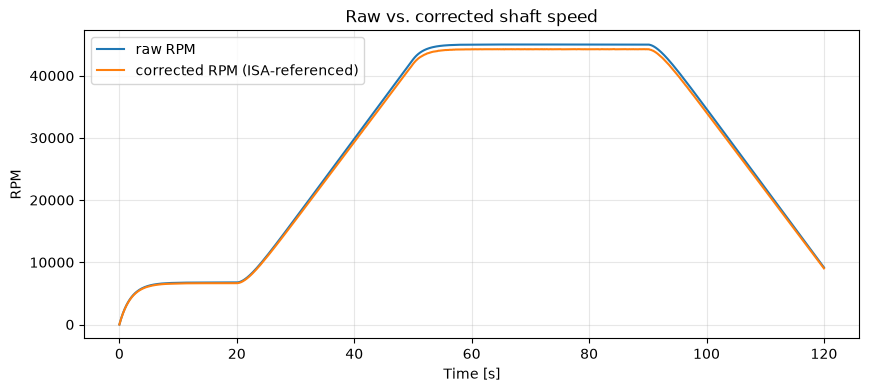

In [4]:
reduced_df = corrected_speed.add_corrected_parameters(calibrated_df)

plt.figure(figsize=(10, 4))
plt.plot(reduced_df["time_s"], reduced_df["rpm"], label="raw RPM")
plt.plot(reduced_df["time_s"], reduced_df["rpm_corrected"], label="corrected RPM (ISA-referenced)")
plt.xlabel("Time [s]")
plt.ylabel("RPM")
plt.title("Raw vs. corrected shaft speed")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. QA flag breakdown

A quick per-rule tally, the same numbers discussed in
`reports/project2_test_data_reduction_report.md`.

In [5]:
qa_df = qa.evaluate_log_qa(reduced_df)
qa_columns = [c for c in qa_df.columns if c.startswith("qa_") and c != "qa_pass"]
qa_df[qa_columns].sum().sort_values(ascending=False)

2026-07-30 08:37:03 | INFO    | jetx.daq.qa | QA evaluation: 55/1201 samples flagged (4.6%)


qa_inlet_pressure_pa_spike           19
qa_inlet_pressure_pa_stuck           12
qa_egt_k_dropout                     10
qa_thrust_n_spike                     7
qa_egt_k_spike                        6
qa_rpm_spike                          2
qa_thrust_n_out_of_range              0
qa_thrust_n_dropout                   0
qa_egt_k_out_of_range                 0
qa_egt_k_stuck                        0
qa_thrust_n_stuck                     0
qa_inlet_pressure_pa_dropout          0
qa_inlet_pressure_pa_out_of_range     0
qa_rpm_dropout                        0
qa_rpm_stuck                          0
qa_rpm_out_of_range                   0
dtype: int64